#Vanishing Gradient Decent
**Weights are too small,**
w * = 0.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
  return x*(1-x)

In [ ]:
layers = 10
weights = [np.random.randn() * 0.1 for _ in range(layers)]
biases = [np.random.randn() * 0.1 for _ in range(layers)]
x = np.random.randn()

In [ ]:
z = []
a = [x]

for i in range(layers):
    z_i = weights[i] * a[i] + biases[i]
    a_val = sigmoid(z_i)
    z.append(z_i)
    a.append(a_val)

#output error
dA = np.random.randn() * 0.1

gradients = []

for i in reversed(range(layers)):
    dZ = dA * sigmoid_derivative(z[i])
    gradients.append(abs(dZ))
    dA = weights[i] * dZ

gradients.reverse()

print("Gradient magnitudes per layer:")
print(gradients)

Gradient magnitudes per layer:
[np.float64(2.042145771593959e-30), np.float64(8.010528442686688e-28), np.float64(5.1578909910197706e-24), np.float64(5.119900371961261e-22), np.float64(4.882723895307232e-19), np.float64(1.3323254826822854e-14), np.float64(8.877220022826406e-13), np.float64(2.1791378617221888e-09), np.float64(4.3306614544013033e-07), np.float64(0.00010201908069552448)]


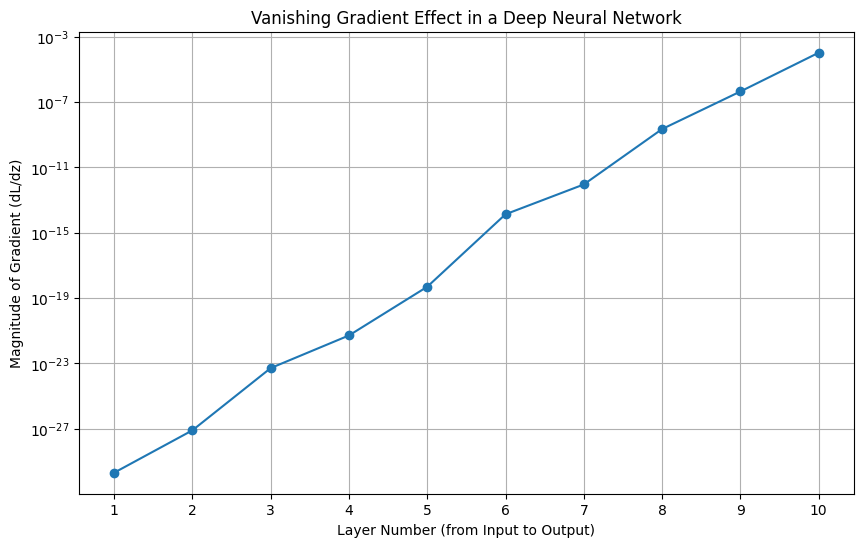

As you can see, the gradient magnitudes decrease significantly for layers closer to the input, demonstrating the vanishing gradient effect. This makes it difficult for the network to learn features in earlier layers.


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, layers + 1), gradients, marker='o')
plt.title('Vanishing Gradient Effect in a Deep Neural Network')
plt.xlabel('Layer Number (from Input to Output)')
plt.ylabel('Magnitude of Gradient (dL/dz)')
plt.yscale('log') # Use log scale to better visualize small values
plt.grid(True)
plt.xticks(range(1, layers + 1))
plt.show()

print("As you can see, the gradient magnitudes decrease significantly for layers closer to the input, demonstrating the vanishing gradient effect. This makes it difficult for the network to learn features in earlier layers.")

#Exploding Gradient Decent
**Weights are too Large,**
w * = 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ReLU activation and derivative
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Network settings
layers = 10

# Force large positive weights to guarantee explosion
weights = [np.abs(np.random.randn()) * 5 for _ in range(layers)]
biases = [np.abs(np.random.randn()) * 5 for _ in range(layers)]

# Positive input to avoid dead ReLU
x = np.abs(np.random.randn())

# ---------- Forward pass ----------
z = []
a = x

for i in range(layers):
    z_i = weights[i] * a + biases[i]
    a = relu(z_i)
    z.append(z_i)

# Initial output error
dA = 1.0

# ---------- Backward pass ----------
gradients = []

for i in reversed(range(layers)):
    dZ = dA * relu_derivative(z[i])
    gradients.append(abs(dZ))
    dA = weights[i] * dZ   # Exploding happens here

gradients.reverse()

print("Gradient magnitudes per layer:")
print(gradients)


Gradient magnitudes per layer:
[np.float64(10484.741517627506), np.float64(3307.911940956945), np.float64(326.6843493145322), np.float64(350.41758054085824), np.float64(105.90049787841986), np.float64(24.846634582570754), np.float64(6.270279975690676), np.float64(10.929883994179175), np.float64(4.328775970850607), np.float64(1.0)]


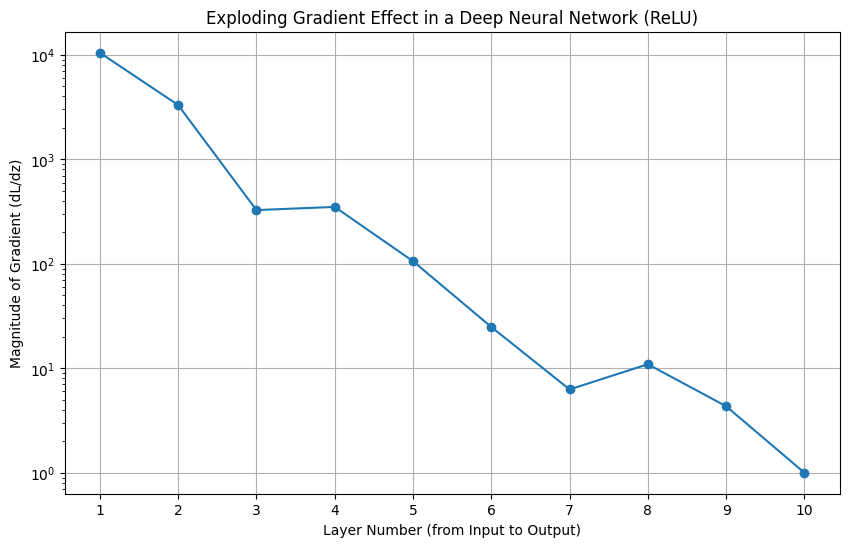

As you can see, the gradient magnitudes increase dramatically for layers closer to the input. This demonstrates the exploding gradient problem, where large weights and ReLU activation cause gradients to grow exponentially during backpropagation.


In [ ]:
# ---------- Visualization ----------
plt.figure(figsize=(10, 6))
plt.plot(range(1, layers + 1), gradients, marker='o')
plt.title('Exploding Gradient Effect in a Deep Neural Network (ReLU)')
plt.xlabel('Layer Number (from Input to Output)')
plt.ylabel('Magnitude of Gradient (dL/dz)')
plt.yscale('log')   # Log scale to clearly show explosion
plt.grid(True)
plt.xticks(range(1, layers + 1))
plt.show()

print(
    "As you can see, the gradient magnitudes increase dramatically for layers "
    "closer to the input. This demonstrates the exploding gradient problem, "
    "where large weights and ReLU activation cause gradients to grow exponentially "
    "during backpropagation."
)

#Symmetry Problem
**All Weights are initialized same,**
w = 0 or w = 0.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid activation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Network settings
layers = 10
weights = [0.1 for _ in range(layers)]
biases = [0.1 for _ in range(layers)]

# Input
x = 1.0

# ---------- Forward pass ----------
z_values = []
a_values = []

a = x
for i in range(layers):
    z_i = weights[i] * a + biases[i]
    a = sigmoid(z_i)
    z_values.append(z_i)
    a_values.append(a)

print("Z values per layer:")
print(z_values)
print("Activations per layer:")
print(a_values)

dA = 1.0

# ---------- Backward pass ----------
gradients = []

for i in reversed(range(layers)):
    dZ = dA * relu_derivative(z[i])
    gradients.append(abs(dZ))
    dA = weights[i] * dZ   # Exploding happens here

gradients.reverse()

print("Gradient magnitudes per layer:")
print(gradients)

Z values per layer:
[0.2, np.float64(0.1549833997312478), np.float64(0.15386684799635422), np.float64(0.15383909996038134), np.float64(0.153838410348444), np.float64(0.15383839320974838), np.float64(0.15383839278380607), np.float64(0.15383839277322026), np.float64(0.1538383927729572), np.float64(0.15383839277295064)]
Activations per layer:
[np.float64(0.549833997312478), np.float64(0.5386684799635422), np.float64(0.5383909996038133), np.float64(0.53838410348444), np.float64(0.5383839320974836), np.float64(0.5383839278380607), np.float64(0.5383839277322026), np.float64(0.5383839277295718), np.float64(0.5383839277295064), np.float64(0.5383839277295047)]
Gradient magnitudes per layer:
[np.float64(1.0000000000000005e-09), np.float64(1.0000000000000005e-08), np.float64(1.0000000000000005e-07), np.float64(1.0000000000000004e-06), np.float64(1.0000000000000004e-05), np.float64(0.00010000000000000003), np.float64(0.0010000000000000002), np.float64(0.010000000000000002), np.float64(0.1), np.flo

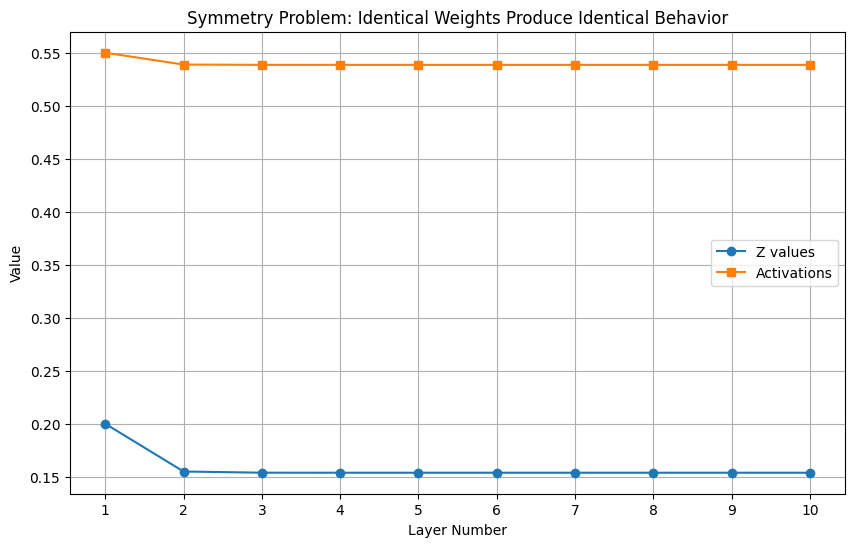

All layers produce very similar outputs because all weights and biases are initialized to the same value. This demonstrates the symmetry problem, where neurons learn identical features.


In [ ]:
# ---------- Visualization ----------
plt.figure(figsize=(10, 6))
plt.plot(range(1, layers + 1), z_values, marker='o', label='Z values')
plt.plot(range(1, layers + 1), a_values, marker='s', label='Activations')

plt.title('Symmetry Problem :')
plt.xlabel('Layer Number')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(range(1, layers + 1))
plt.legend()
plt.show()

print(
    "All layers produce very similar outputs because all weights and biases "
    "are initialized to the same value. This demonstrates the symmetry problem, "
    "where neurons learn identical features."
)